In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [493]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM','SPY']
df = yf.download(tickers,period= '2Y')["Close"]
df.index = df.index.tz_localize("UTC").tz_convert("Europe/London")
df.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,GOOGL,JPM,MSFT,SPY
Date,,,,,
2024-06-10 01:00:00+01:00,191.461472,173.670898,191.363922,421.249725,522.933289
2024-06-11 01:00:00+01:00,205.370987,175.268555,186.330811,425.985321,524.192749
2024-06-12 01:00:00+01:00,211.240173,176.429626,183.617722,434.235657,528.497986
2024-06-13 01:00:00+01:00,212.400101,173.819748,185.659729,434.747589,529.562073
2024-06-14 01:00:00+01:00,210.665115,175.437256,185.774765,435.722260,529.884277


In [497]:
yf.Ticker("A").info.get("shortName")

'Agilent Technologies, Inc.'

In [489]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 500 entries, 2024-06-10 01:00:00+01:00 to 2026-06-08 01:00:00+01:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    500 non-null    float64
 1   GOOGL   500 non-null    float64
 2   JPM     500 non-null    float64
 3   MSFT    500 non-null    float64
 4   SPY     500 non-null    float64
dtypes: float64(5)
memory usage: 23.4 KB


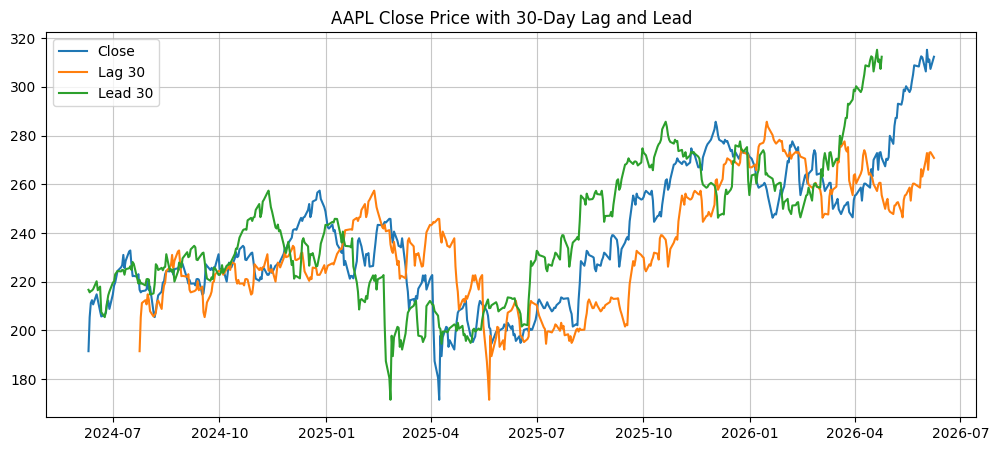

In [237]:
plt.figure(figsize=(12,5))
plt.plot(apple["Close"],label='Close')
plt.plot(apple["Close"].shift(30),label='Lag 30')
plt.plot(apple["Close"].shift(-30),label='Lead 30')
plt.grid(alpha=0.7)
plt.legend()
plt.title("AAPL Close Price with 30-Day Lag and Lead")
plt.show()

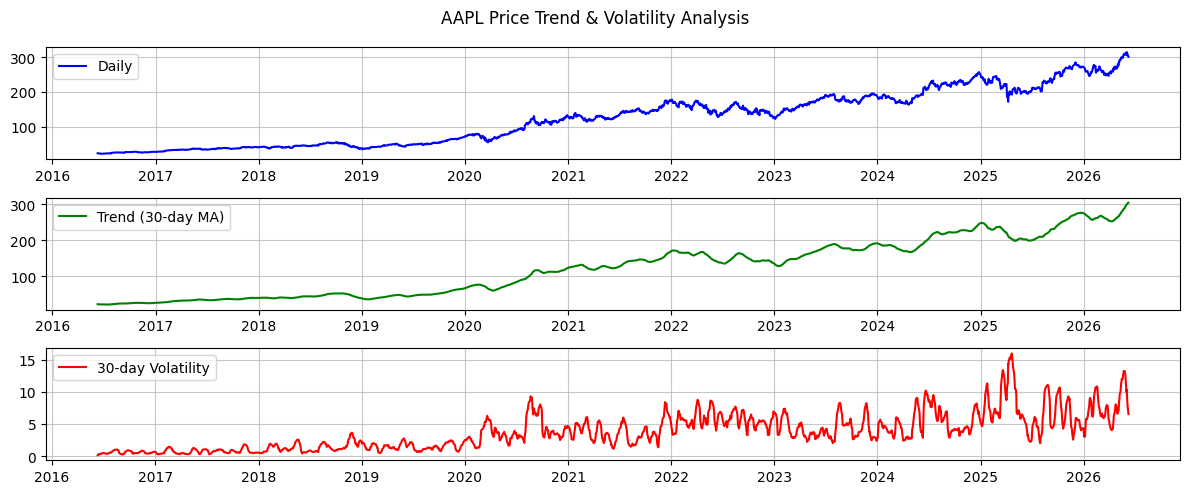

In [358]:
fig, axes = plt.subplots(3,1,figsize=(12,5))
axes[0].plot(apple["Close"],'b-',label="Daily")
axes[1].plot(apple["Close"].rolling(window='30D').mean(),'g-',label="Trend (30-day MA)")
axes[2].plot(apple["Close"].rolling(window='30D').std(),'r-',label="30-day Volatility")
for ax in axes:
    ax.grid(alpha=0.7)
    ax.legend()
plt.suptitle("AAPL Price Trend & Volatility Analysis")
plt.tight_layout()
plt.show()

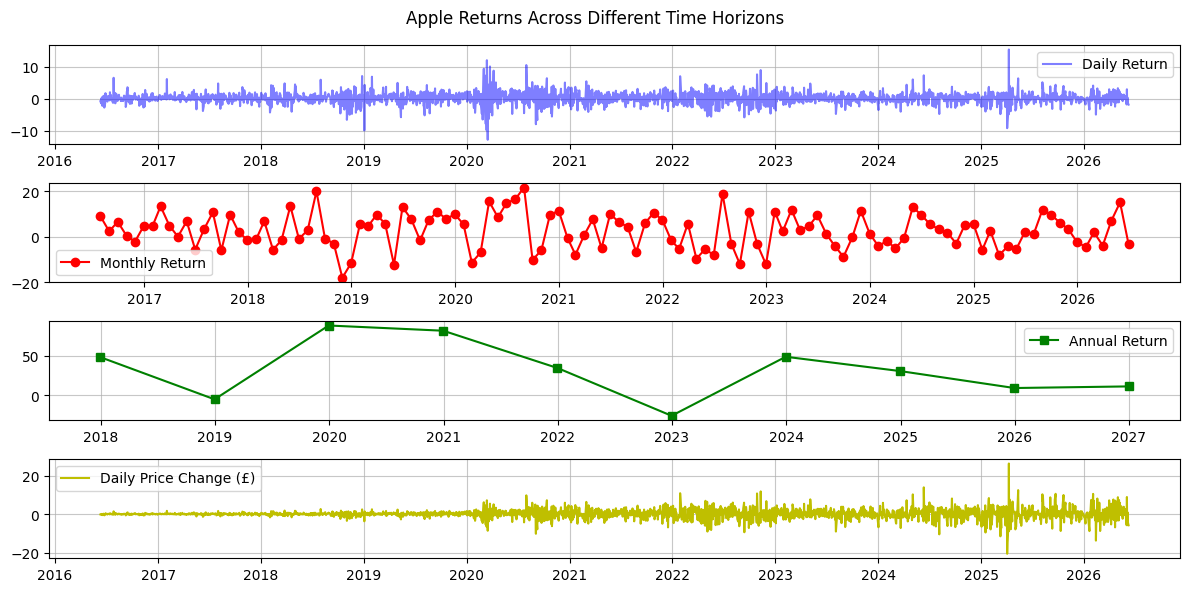

In [381]:
fig, axes = plt.subplots(4,1,figsize=(12, 6))
axes[0].plot(apple["Close"].pct_change(periods=1).mul(100),
             'b-',label="Daily Return",alpha=0.5)
axes[1].plot(apple["Close"].resample("ME").last().pct_change(periods=1).mul(100),
             'ro-',label="Monthly Return")
axes[2].plot(apple["Close"].resample("YE").last().pct_change(periods=1).mul(100),
             'gs-',label="Annual Return")
axes[3].plot(apple["Close"].diff(),'y-',label = "Daily Price Change (£)")
plt.suptitle("Apple Returns Across Different Time Horizons")
plt.tight_layout()
for ax in axes:
    ax.grid(alpha=0.7)
    ax.legend()
plt.show()

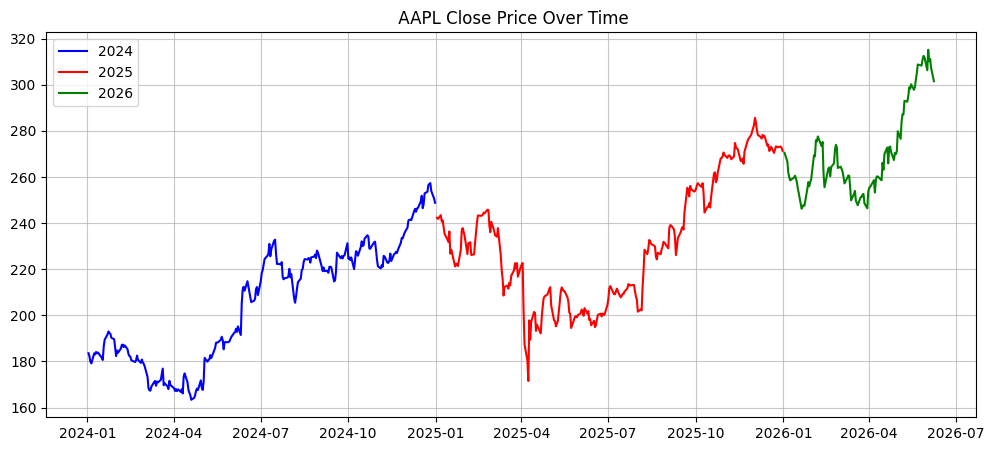

In [360]:
plt.figure(figsize=(12,5))
plt.plot(apple.loc[apple.index.year==2024,"Close"],'b',label='2024',)
plt.plot(apple.loc[apple.index.year==2025,"Close"],'r',label='2025')
plt.plot(apple.loc[apple.index.year==2026,"Close"],'g',label='2026')
plt.title(" AAPL Close Price Over Time")
plt.legend()
plt.grid(alpha=0.7)
plt.show()

<Axes: xlabel='Date'>

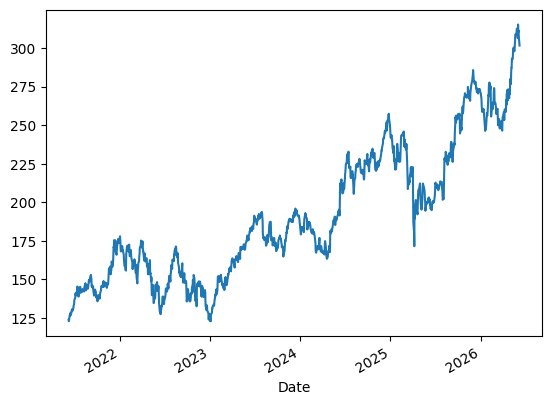

In [442]:
df["AAPL"].plot()

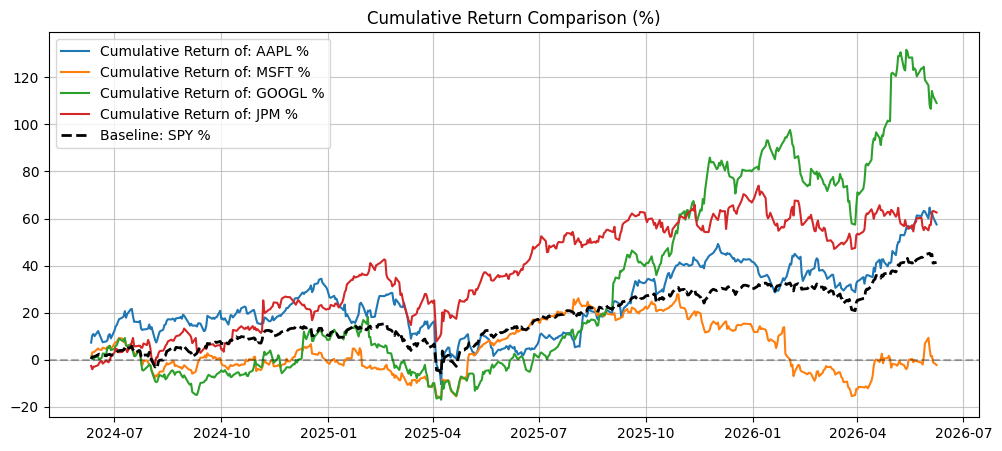

In [ ]:
plt.figure(figsize=(12,5))
hashmap ={}c
for ticker in tickers:
    cumulative_return = df[ticker].pct_change().add(1).cumprod().sub(1).mul(100)
    hashmap[ticker] = cumulative_return
    if ticker != 'SPY':
        plt.plot(cumulative_return,label = f"Cumulative Return of: {ticker} %")
    
    else:
        plt.plot(cumulative_return, 'k--', linewidth=2,label = f"Baseline: {ticker} %")
plt.axhline(0, linestyle='--', color='black', alpha=0.3)
plt.legend()
plt.grid(alpha=0.7)
plt.title("Cumulative Return Comparison (%)")
plt.show()

In [479]:
hashmap["AAPL"].iloc[-1]

np.float64(57.49384464844232)

In [457]:
def profit_calculator(initial_investment=1000):
    cumulative_return = apple["Close"].pct_change().add(1).cumprod().sub(1)
    profit = cumulative_return.dropna().iloc[-1] * initial_investment
    print(f"Initial Investment : £{initial_investment:,.2f}")
    print(f"Profit             : £{profit:,.2f}")
    print(f"Final Value        : £{initial_investment + profit:,.2f}")
    return profit
profit_calculator(1000)

Initial Investment : £1,000.00
Profit             : £12,292.31
Final Value        : £13,292.31


np.float64(12292.31483252577)

In [464]:
apple["Close"].iloc[-1]

np.float64(301.5400085449219)

In [550]:
def fetch_from_yahoo (tickers:list=['AAPL', 'MSFT', 'SPY']) -> pd.DataFrame:
    
        df = yf.download(tickers,period = '5Y')["Close"]
        df.index = df.index.tz_localize("UTC").tz_convert("Europe/London")
        return df
stock = fetch_from_yahoo('AAPL')

[*********************100%***********************]  1 of 1 completed


In [553]:
stock

Ticker,AAPL
Date,
2021-06-09 01:00:00+01:00,123.920212
2021-06-10 01:00:00+01:00,122.925964
2021-06-11 01:00:00+01:00,124.134628
2021-06-14 01:00:00+01:00,127.185654
2021-06-15 01:00:00+01:00,126.366859
...,...
2026-06-02 01:00:00+01:00,315.200012
2026-06-03 01:00:00+01:00,310.260010
2026-06-04 01:00:00+01:00,311.230011
